<img src="./imagenes/logo_UTN.svg" align="right" width="200"/>

# **Teoría de Circuitos II**
## Informe Trabajo Practico de Laboratorio 1

---
**Profesor:** Mariano Llamedo Soria \
**Ayudante de TPs:** David Moharos \
**Jefe de TPs:** César Fuoco

**Grupo 5** \
**Integrantes**: Campos Hernán Leonel, Dorrego Valentin Aníbal, Yrcañaupa Pérez Josué Alfredo\
**Alumno:** Valentin Dorrego\
**Curso:** R4052\
**Ciclo lectivo:** 2026  

---

**Objetivos**
Consolidar los conceptos de teoría moderna mediante la implementación circuital.
Simular e implementar el filtro con componentes activos de precisión.
Medir las partes de la función transferencia para frecuencias menores a 100 kHz.

**Descripción**

El trabajo práctico consiste en el diseño, análisis, medición y discusión de un filtro activo.

- Plantilla asignada:
<div align="center">
  <img src="imagenes/Tpl1/Plantilla.png" width="700">
  <figcaption>Figura 1: Plantilla de diseño.</figcaption>
</div>

---

## Resolucion
### Resolucion prototipo:

Es evidente que se nos fue asignado un filtro Chebyshev del tipo Pasabajos, por ende pasamos a realizar nuestra funcion prototipo.

Tenemos:
- $\omega_p=1.5kHz$
- $\omega_s=4.5kHz$
- $\alpha_{max}=0.5db$
- $\alpha_{min}=16db$

Normalizando con $\omega_s$ nos queda:
- $\omega_p=1$
- $\omega_s=3$

Una vez obtenida la plantilla equivalente del filtro, comenzamos a obtener los parametros de nuestro filtro pasabajos prototipo de Chebychev.
$$
\begin{aligned}
|T(j\omega)|^2=\frac{1}{1+\xi^2 \cdot C_n^{2}(\omega)}
\end{aligned}
$$

Determinamos el orden del filtro
$$
\begin{align}
\xi^2 &= 10^{\frac{\alpha_{max}}{10}}-1 = 0.122
\end{align}
$$

$$
\begin{align}
\alpha_n &= 10\cdot \log\left(1+\xi^2\cdot \cosh^2(n\cdot \cosh^{-1}(\omega_s))\right)
\end{align}
$$
Iterando $n$ hasta que $\alpha_n > \alpha_{min}$ obtenemos que el filtro deberá ser de orden $n=3$ para que cumpla con la atenucación pedida.

Debemos calcular las raices del denominador.
Las funciones armonica de Chebyshevpuede ser expresadas por equivalentes polinomios que siguen una forma recursiva de serie:
$$
\begin{align}
C_n(\omega) = 2 \cdot C_{n-1}(\omega) - C_{n-2}(\omega) \quad \text{con} \quad C_0(\omega)=1 \quad \text{y} \quad C_1(\omega)=\omega 
\end{align}
$$
Entonces para $n = 2%$ tenemos
$$
\begin{align}
C_2(\omega) = 2 \cdot C_1(\omega) - C_0(\omega) = 2\cdot\omega^2-1  
\end{align}
$$
Y para $n = 3%$ tenemos
$$
\begin{align}
C_3(\omega) = 2 \cdot \omega C_2(\omega) - C_1(\omega) = 2\cdot\omega(2\cdot\omega^2-1)-\omega = 4\cdot\omega^3 - 2\cdot\omega -\omega = 4\cdot\omega^3-3\omega  
\end{align}
$$

Reenplazando nos queda:
$$
\begin{aligned}
|T(j\omega)|^2=\frac{1}{1+\xi^2 \cdot C_n^{2}(\omega)} =\frac{1}{1+\xi^2 \cdot (4\cdot\omega^{3}-3\omega)}=\frac{\frac{1}{16\cdot\xi^{2}}}{-s^6-s^4\cdot\frac{3}{2}-s^2\cdot\frac{9}{16}+\frac{1}{16\cdot\xi^2}}
\end{aligned}
$$
Como sabemos que $2N=6$, entonces $|H(s)|$ tiene un denominador cuyo polinomio es de grado 3 y $H(-s)$ tambien.
$$
\begin{aligned}
|T(s)|\cdot|T(-s)|= \frac{1}{(s^3+a\cdot s^2+b\cdot s+c)\cdot(-s^3+a\cdot s^2-b\cdot s+c)}
\end{aligned}
$$
Trabajando un poco algebraicamente llegamos a
$$
\begin{aligned}
\frac{\frac{1}{16\cdot\xi^{2}}}{-s^6-s^4\cdot\frac{3}{2}-s^2\cdot\frac{9}{16}+\frac{1}{16\cdot\xi^2}} = \frac{1}{(-s^6+0\cdot^5+(a^2-2b)\cdot s^4+(0)\cdot s^3+(2ac-b^2)\cdot s^2+c^2)}
\end{aligned}
$$
Igualando termino a termino obtenemos
$$
\begin{aligned}
a=1,25\\
b=1,53\\
c=1,25
\end{aligned}
$$
Entonces terminamos obteniendo nuestra funcion transferencia Pasabajos prototipo
$$
\begin{aligned}
T_{lp}(s)=\frac{0.715}{s^3+1,25\cdot s^2+1,53\cdot s+0,715}
\end{aligned}
$$


### Resolucion topologia:

Como tenemos un filtro pasabajos de orden tres, lo implementaremos en dos etapas, una activa de segundo orden en cascada con una pasiva de primer orden, ambos filtros de la forma $T(s)=\frac{1}{Q(s)}$

Pasamos a factorizar el denominador de nuestra transferencia, teniendo como resultado 
$$
\begin{aligned}
T_{lp}(s)=\frac{0.715}{(s+0.626)(s^2+0,627\cdot s+1,142)}
\end{aligned}
$$

Como no hay requisistos para la ganancia en la banda de paso optamos por tener ganancia unitaria.

$$
|T_{1}| = \left( 0,626\right)\cdot\left(\frac{1}{s+0,626}\right)
$$
$$
|T_{2}| = \left( 1,142\right)\cdot\left(\frac{1}{s^2+(0,627)s+1,142}\right)
$$

Como primera etapa tomamos un RC pasabajos, para la segunda etapa optamos por la configuracion Sallen-Key Pasabajos:

<div align="center">
  <img src="imagenes/Tpl1/Sallen-Key.png" width="400">
  <figcaption>Figura 2: Topologia Sallen-Key Pasabajos.</figcaption>
</div>

$$
|T_{RC}| = \left( \frac{1}{C_1}\right)\cdot\left(\frac{1}{s+\frac{1}{C_1\cdot R_1}} \right) \qquad \text{Para el RC Pasabajos}
$$
$$
|T_{SK}| = \left( \frac{G_2G_3}{C_2C_3}\right)\cdot\left(\frac{1}{s^2+s\frac{1}{C_3}\cdot\left(G_2+G_3\right)+\frac{G_2G_3}{C_2C_3}} \right) \qquad \text{Para el Sallen-Key}
$$


### Resolucion  desnomalizacion

Para la sintetizar nuestros circuitos realizamos $|T_{RC}|=|T_1(s)|$ y $|T_{SK}(s)|=|T_2(s)|$.
Tomamos $R1=R2=R3=1$ quedandonos los capacitores:

- C1 = 1,6
- C2 = 0,274
- C3 = 3,19

Con estas valores procedemos a desnomalizar nuestros componentes

$$
C1 = \frac{1,6}{2\pi\cdot1,5kHz\cdot Rn} \qquad \text{Para $C1 = 100nF$, $Rn = 1697\ohm$}
$$
$$
C2 = \frac{0.274}{2\pi\cdot1,5kHz\cdot 1697\ohm} \qquad \text{$C2 = 17nF \approx 15nF$}
$$
$$
C3 = \frac{3.19}{2\pi\cdot1,5kHz\cdot 1697\ohm} \qquad \text{$C3 = 200nF$}
$$
$$
R1 = R2 = R3 = 1697\ohm
$$

Como Amplificador operacional utilizaremos el **Opa2335** de **Texas Instruments**, [ver datasheet](https://www.ti.com/lit/ds/symlink/opa335.pdf?.ts=1786180657375).


### Simulaciones

Realizamos las simulaciones del filtro en PSpice, debido que en este simulador tenemos la familia del Amplificador operaciones con el que trabajamos.

<div align="center">
  <img src="imagenes/Tpl1/Circuito.png" width="800">
      <figcaption>Figura 3: Circuito desnomalizado.</figcaption>
</div>
   
<div align="center">
  <img src="imagenes/Tpl1/ModuloYFase.png" width="800">
  <figcaption>Figura 4: Grafica en módulo y fase.</figcaption>
</div>

Identificamos el rizado tipico de los filtros por aproximacion Chebyshev, "tocando" 3 veces los 0db a causa de ser de grado 3.



<div align="center">
  <img src="imagenes/Tpl1/alphaMax.png" width="800">
  <figcaption>Figura 5: Atenuacion maxima en $1,5kHz$.</figcaption>
</div>

Verificamos que el filtro cumple con una atenuacion menor a los 0.5db en $1,5kHz$ pedidos por la plantilla.

<div align="center">
  <img src="imagenes/Tpl1/alphaMin.png" width="800">
  <figcaption>Figura 6: Atenuacion minima en $4,5kHz$.</figcaption>
</div>

Verificamos que el filtro cumple con una atenuacion mayor a los 16db en $4,5kHz$ pedidos por la plantilla.


### Placa del filtro

El circuito lo implementamos en un PCB para facilitar las mediciones el dia del laboratorio en clase.

<div align="center">
  <img src="imagenes/Tpl1/CircuitoAltium.png" width="700">
  <figcaption>Figura 7: Circuito esquematico del PCB.</figcaption>
</div>

<div align="center">
  <img src="imagenes/Tpl1/PCB.png" width="400">
  <figcaption>Figura 8: PCB.</figcaption>
</div>

<div align="center">
  <img src="imagenes/Tpl1/IMG_0053.png" width="400">
  <figcaption>Figura 8: Top layer overview.</figcaption>
</div>

<div align="center">
  <img src="imagenes/Tpl1/IMG_0054.png" width="400">
  <figcaption>Figura 8: Bottom layer overview.</figcaption>
</div>

En el diseño utilizamos resistencias variables, para poder aproximarnos mejor a los resultados deseados y tambien añadimos puntos de prueba para facilitar las mediciones de interés.

### Resultados de las mediciones


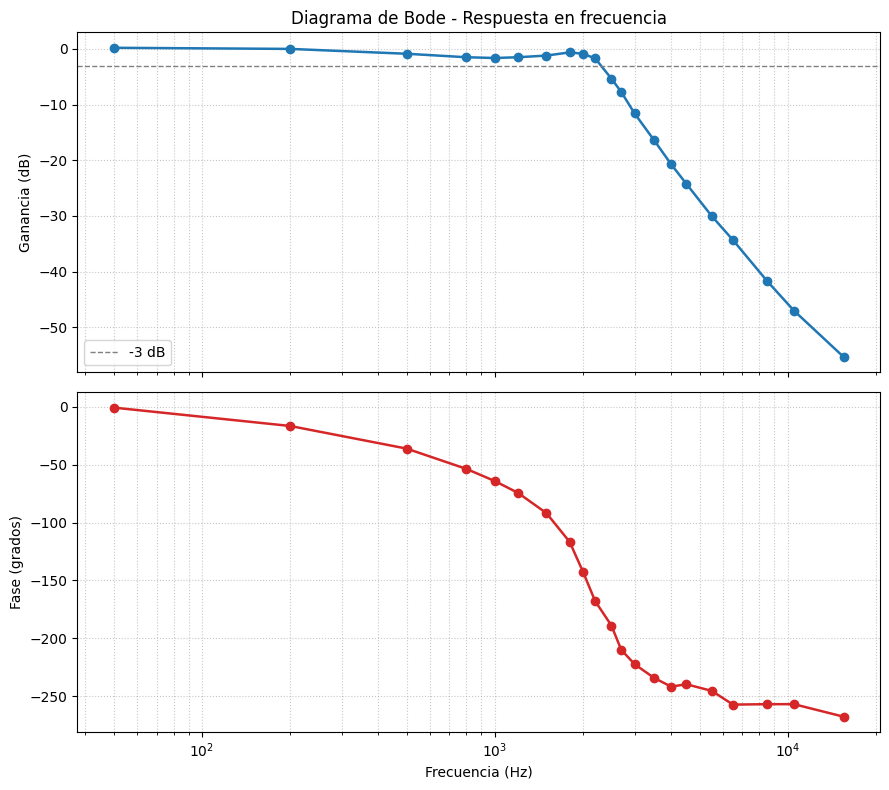

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1) Datos medidos
# ---------------------------------------------------------------
# frec(Hz), Vin_pp, Vout_pp, Amp(veces), Aten(dB), dT(s), Fase(deg)
datos = [
    (50,    3,    3.07,  1.023333333,  0.200342415,  0.00003, -0.54),
    (200,   3,    3.00,  1.0,          0.0,          0.000228, -16.416),
    (500,   3.03, 2.74,  0.904290429, -0.873841314,  0.0002,  -36.0),
    (800,   3.03, 2.55,  0.841584158, -1.498048961,  0.000186, -53.568),
    (1000,  3.03, 2.51,  0.828382838, -1.63537814,   0.000178, -64.08),
    (1200,  3.03, 2.55,  0.841584158, -1.498048961,  0.000172, -74.304),
    (1500,  3.03, 2.64,  0.871287129, -1.196774033,  0.00017,  -91.8),
    (1800,  3,    2.79,  0.93,        -0.630341029,  0.00018,  -116.64),
    (2000,  3.03, 2.74,  0.904290429, -0.873841314,  0.000198, -142.56),
    (2200,  2.92, 2.40,  0.821917808, -1.703432195,  0.000212, -167.904),
    (2500,  2.92, 1.58,  0.54109589,  -5.33451529,   0.00021,  -189.0),
    (2700,  2.92, 1.20,  0.410958904, -7.724032108,  0.000216, -209.952),
    (3000,  2.92, 0.768, 0.263013699, -11.60043263,  0.000206, -222.48),
    (3500,  2.92, 0.44,  0.150684932, -16.4386035,   0.000186, -234.36),
    (4000,  2.92, 0.268, 0.091780822, -20.74496115,  0.000168, -241.92),
    (4500,  2.92, 0.18,  0.061643836, -24.20220693,  0.000148, -239.76),
    (5500,  2.92, 0.092, 0.031506849, -30.03190048,  0.000124, -245.52),
    (6500,  2.92, 0.056, 0.019178082, -34.34389649,  0.00011,  -257.4),
    (8500,  2.92, 0.024, 0.008219178, -41.70343219,  0.000084, -257.04),
    (10500, 2.92, 0.013, 0.004452055, -47.02878998,  0.000068, -257.04),
    (15500, 2.92, 0.005, 0.001712329, -55.32825694,  0.000048, -267.84),
]

datos = np.array(datos)
freq   = datos[:, 0]
vin    = datos[:, 1]
vout   = datos[:, 2]
amp    = datos[:, 3]
aten_db = datos[:, 4]
dt     = datos[:, 5]
fase   = datos[:, 6]

# ---------------------------------------------------------------
# 2) Diagrama de Bode: Amplitud (dB) y Fase, ambos vs frecuencia (log)
# ---------------------------------------------------------------
fig, (ax_amp, ax_fase) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# --- Amplitud ---
ax_amp.semilogx(freq, aten_db, marker='o', color='tab:blue', linewidth=1.8)
ax_amp.axhline(-3, color='gray', linestyle='--', linewidth=1, label='-3 dB')
ax_amp.set_ylabel('Ganancia (dB)')
ax_amp.set_title('Diagrama de Bode - Respuesta en frecuencia')
ax_amp.grid(True, which='both', linestyle=':', alpha=0.7)
ax_amp.legend(loc='lower left')

# --- Fase ---
ax_fase.semilogx(freq, fase, marker='o', color='tab:red', linewidth=1.8)
ax_fase.set_ylabel('Fase (grados)')
ax_fase.set_xlabel('Frecuencia (Hz)')
ax_fase.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('bode_amplitud_fase.png', dpi=150)
plt.show()

Medimos la transferencia del filtro y la fase del mismo, se pudo verificar en primera instancia respondió como lo habiamos esperado, cumpliendo con la plantilla asignada.

### Medicion con analalizador de redes

Luego pasamos a realizar la mediciones de modulo y fase con el equipo docente, pero esta vez utilizando el **analizador de redes** en el cual obtuvimos los siguientes resultados:

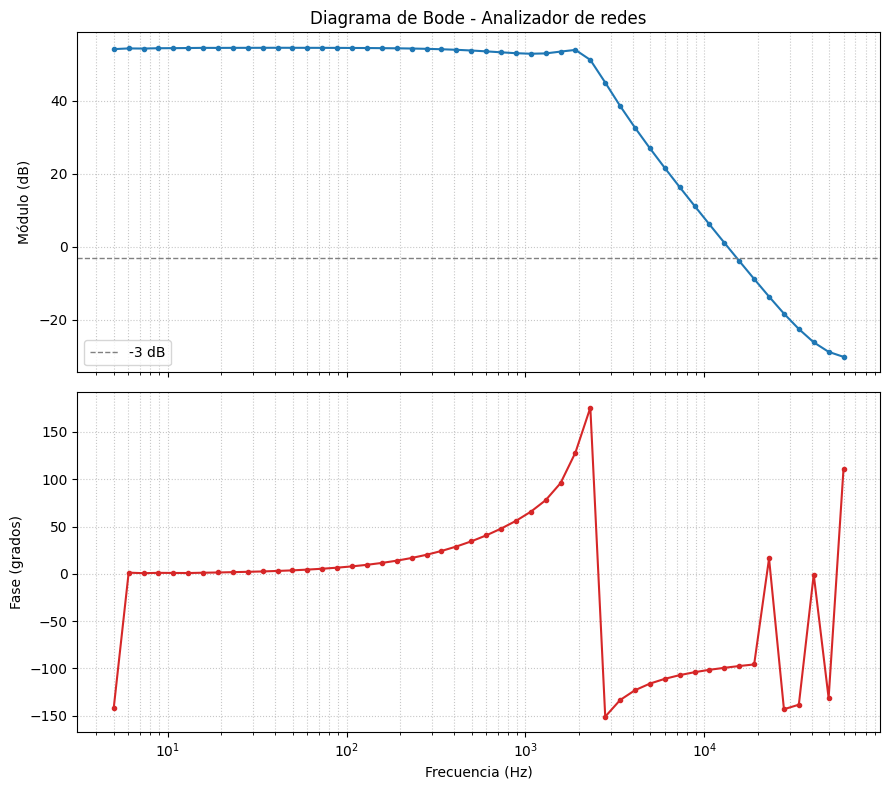

Gráfico guardado: bode_analizador_redes.png
Puntos módulo: 50 | Puntos fase: 50


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

ARCHIVO_MODULO = r"C:\Users\valen\OneDrive\Documentos\Facultad\2026\tc2\myRepo\jupyterNotebooks\Scripts\Sweep_Modulo.csv"
ARCHIVO_FASE = r"C:\Users\valen\OneDrive\Documentos\Facultad\2026\tc2\myRepo\jupyterNotebooks\Scripts\Sweep_Data_0.csv"

def leer_bloque(path, nombre_funcion_contiene, n_filas_max=200):
    """
    Lee un CSV multi-bloque tipo 'Sweep' y devuelve el DataFrame del bloque
    cuyo título (2da línea del bloque) contiene 'nombre_funcion_contiene'.
    """
    with open(path, encoding="utf-8-sig") as f:
        lineas = f.readlines()

    # Encontrar los índices donde arranca cada bloque ("Sweep - Function N")
    inicios = [i for i, l in enumerate(lineas) if l.startswith('"Sweep - Function')]
    inicios.append(len(lineas))  # centinela final

    for k in range(len(inicios) - 1):
        inicio, fin = inicios[k], inicios[k + 1]
        titulo = lineas[inicio + 1]
        if nombre_funcion_contiene.lower() in titulo.lower():
            encabezado = inicio + 2  # línea con nombres de columnas
            bloque = lineas[encabezado:fin]
            # Filtrar líneas vacías al final del bloque
            bloque = [l for l in bloque if l.strip() != ""]
            from io import StringIO
            df = pd.read_csv(StringIO("".join(bloque)))
            df.columns = [c.strip().strip('"') for c in df.columns]
            return df

    raise ValueError(f"No se encontró un bloque que contenga '{nombre_funcion_contiene}' en {path}")


# ---------------------------------------------------------------
# 1) Leer módulo (dB) y fase (deg)
# ---------------------------------------------------------------
df_mod = leer_bloque(ARCHIVO_MODULO, "Vac vs Frequency")
df_fase = leer_bloque(ARCHIVO_FASE, "Phase vs Frequency")

freq_mod = df_mod["X (Hz)"]
mod_db = df_mod["Ch-1 (dBr)"]

freq_fase = df_fase["X (Hz)"]
fase_deg = df_fase["Ch-2 (deg)"]  # Ch-1 es el canal de referencia (siempre 0)

# ---------------------------------------------------------------
# 2) Diagrama de Bode: Módulo (dB) y Fase, ambos vs frecuencia (log)
# ---------------------------------------------------------------
fig, (ax_mod, ax_fase) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax_mod.semilogx(freq_mod, mod_db, marker='o', markersize=3, color='tab:blue', linewidth=1.5)
ax_mod.axhline(-3, color='gray', linestyle='--', linewidth=1, label='-3 dB')
ax_mod.set_ylabel('Módulo (dB)')
ax_mod.set_title('Diagrama de Bode - Analizador de redes')
ax_mod.grid(True, which='both', linestyle=':', alpha=0.7)
ax_mod.legend(loc='lower left')

ax_fase.semilogx(freq_fase, fase_deg, marker='o', markersize=3, color='tab:red', linewidth=1.5)
ax_fase.set_ylabel('Fase (grados)')
ax_fase.set_xlabel('Frecuencia (Hz)')
ax_fase.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('bode_analizador_redes.png', dpi=150)
plt.show()

print("Gráfico guardado: bode_analizador_redes.png")
print(f"Puntos módulo: {len(freq_mod)} | Puntos fase: {len(freq_fase)}")


Notamos a primera vista que en la respuesta de modulo, nuestra banda de paso se encuentra en $\approx 50db$ esto es meramente por un tema de referencia del instrumento, simplemente no fue calibrado antes de la medicion y tenemos este offset, pero realmente la banda de paso se encuentra en $0db$. Luego en la respuesta de fase notamos un salto de discontinuidad pero esto es normal debido a que el instrumento trabaja en rangos de entre $180° a -180°$, tambien al ir aumentando la frecuencia, los valores de la señal de salida comienzan a ser tan pequeños que ya la medicion de fase comienza a tener este comportamiento errático. La fase va de forma "Creciente" porque el intrumento realiza la medicion de fase con el signo cambiado, de todas formas el filtro cumple con el diseño pedido.

---

## Conclusiones
A lo largo del trabajo práctico pudimos poner a prueba nuestros conocimientos sobre el diseño de filtros y los distintos tipos de aproximaciones vistos en la teoría, implementándolos en el laboratorio. Esto nos enfrentó a obstáculos que la teoría no contempla, como la elección de amplificadores operacionales adecuados y el trabajo con valores de componentes que efectivamente pudiéramos conseguir localmente. También debimos tener en cuenta criterios de diseño de los que las simulaciones nos eximen, como el hecho de ubicar la etapa de mayor impedancia de entrada al comienzo del circuito: implementar una etapa de baja impedancia de entrada como primera etapa puede "cargar" al generador, alterando las mediciones.


---

## Anexo Calculos

[Ver PDF](https://github.com/ValentinDorrego/tc2/blob/main/jupyterNotebooks/Pdfs/TPLab1Res.pdf)

In [3]:
from IPython.display import display, HTML

display(HTML("""
<div style="display: flex; justify-content: center;">
    <iframe src="./Pdfs/TPLab1Res.pdf" width="900" height="900"></iframe>
</div>
"""))